# HQPINN Interactive Notebook

This notebook is a short interactive reproduction of the **DHO** benchmark from HQPINN.

We keep only three models:
- `cc`
- `hy-m`
- `qq-m`

and we focus on the paper-style comparison metrics:
- **Trainable parameters**
- **Relative L2 error**
- **Learning time**

The training launched here uses the project code directly, so the notebook does **not** reimplement a custom loss or a separate training loop. The notebook also forces retraining so it does not silently reuse older checkpoints.

## Notebook Map

1. inspect the exact damped oscillator solution
2. launch training for `cc`, `hy-m`, and `qq-m`
3. read the latest runs from the DHO summary file
4. compare only the paper-facing metrics
5. visualize the final learned trajectories


In [15]:
from __future__ import annotations

import csv
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "HQPINN" / "configs").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the current working directory.")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from HQPINN.config import LAMBDA1, LAMBDA2
from HQPINN.lib.DHO.core_dho import u_exact
from HQPINN.lib.runner import train_and_evaluate

DHO_ROOT = REPO_ROOT / "HQPINN" / "lib" / "DHO"
SUMMARY_PATH = DHO_ROOT / "results" / "dho_summary.csv"

TARGET_MODELS = ["cc", "hy-m", "qq-m"]
TRAIN_CONFIGS = {
    "cc": REPO_ROOT / "HQPINN" / "configs" / "dho_cc_train.json",
    "hy-m": REPO_ROOT / "HQPINN" / "configs" / "dho_hy_m_train.json",
    "qq-m": REPO_ROOT / "HQPINN" / "configs" / "dho_qq_m_train.json",
}


def load_dho_rows(summary_path: Path) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []
    with summary_path.open(newline="", encoding="utf-8") as handle:
        for raw in csv.DictReader(handle):
            try:
                rows.append(
                    {
                        "run_id": raw["run_id"],
                        "model": raw["Model"],
                        "size": raw["Size"],
                        "params": int(raw["Trainable parameters"]),
                        "elapsed": float(raw["elapsed time (s)"]),
                        "rel_l2": float(raw["Relative L2 error"]),
                    }
                )
            except (KeyError, ValueError):
                continue
    return rows


def latest_runs_for_models(summary_path: Path, models: list[str]) -> list[dict[str, object]]:
    rows = load_dho_rows(summary_path)
    latest: dict[str, dict[str, object]] = {}
    for row in rows:
        model = str(row["model"])
        if model not in models:
            continue
        current = latest.get(model)
        if current is None or str(row["run_id"]) > str(current["run_id"]):
            latest[model] = row
    return [latest[model] for model in models if model in latest]


def final_png_for(model: str) -> Path | None:
    folder = DHO_ROOT / "results" / f"dho_{model.replace('-', '_')}"
    if not folder.exists():
        return None
    candidates = sorted(path for path in folder.glob("*.png") if "epoch-" not in path.name)
    return candidates[-1] if candidates else None


def family_color(model: str) -> str:
    return {
        "cc": "#4C78A8",
        "hy-m": "#F58518",
        "qq-m": "#54A24B",
    }[model]


training_results: dict[str, dict[str, object]] = {}


def train_selected_model(model: str) -> dict[str, object]:
    config_path = TRAIN_CONFIGS[model]
    print(f"Training {model} with {config_path.relative_to(REPO_ROOT)} ...")
    result = train_and_evaluate(
        {
            "config_path": str(config_path),
            "shared_runner": {"force_retrain": True},
        },
        REPO_ROOT / "runs" / f"notebook-dho-{model}",
    )
    training_results[model] = result
    print(result)
    return result


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

display(Markdown(f"Repo root: `{REPO_ROOT}`"))
display(Markdown(f"Summary file: `{SUMMARY_PATH.relative_to(REPO_ROOT)}`"))


Repo root: `/Users/jerome/git/reproduced_papers_fork`

Summary file: `HQPINN/lib/DHO/results/dho_summary.csv`

## 1. Exact DHO Reference

The DHO benchmark is a good entry point because it is very visual: the model predicts a single damped trajectory, and we can compare it directly to the exact solution.

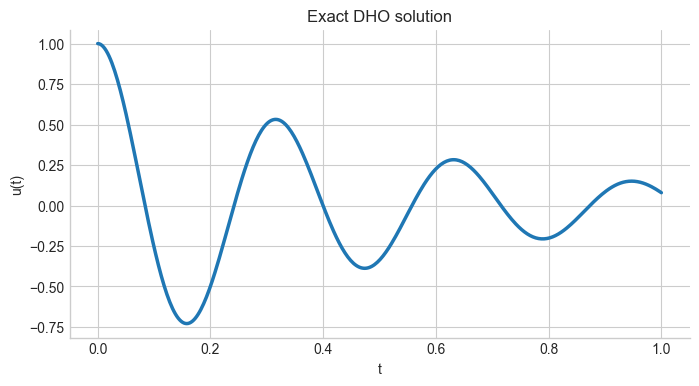

In [16]:
t = np.linspace(0.0, 1.0, 400)
u = u_exact(t)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, u, color="#1f77b4", linewidth=2.5)
ax.set_title("Exact DHO solution")
ax.set_xlabel("t")
ax.set_ylabel("u(t)")
plt.show()


## 2. Train The Three Selected Models

The next three cells launch real training jobs through the shared HQPINN runner for:
- `cc`
- `hy-m`
- `qq-m`

The training uses the **same DHO loss as the scripts**:

$$\mathcal{L} = IC_u + \lambda_1 IC_{du} + \lambda_2 PDE$$

with the current project values:
- `lambda1 = 1e-1`
- `lambda2 = 1e-4`

This will append new rows to `HQPINN/lib/DHO/results/dho_summary.csv`.
Approximate runtime depends on your environment, but `qq-m` is the slowest of the three.

In [17]:
train_selected_model("cc")


Training cc with HQPINN/configs/dho_cc_train.json ...
Latest checkpoint found: HQPINN/lib/DHO/models/dho_cc_20260403-171109.pt
Loaded model from: HQPINN/lib/DHO/models/dho_cc_20260403-171109.pt remote=False
Skipping training for dho_cc: existing checkpoint found at HQPINN/lib/DHO/models/dho_cc_20260403-171109.pt.
Duplicate summary row appended for run_id=20260403-171109 to: HQPINN/lib/DHO/results/dho_summary.csv
Reused checkpoint metrics for dho_cc.

{'status': 'completed', 'run_dir': '/Users/jerome/git/reproduced_papers_fork/runs/notebook-dho-cc', 'experiment': 'dho-cc', 'mode': 'train', 'backend': 'local'}


{'status': 'completed',
 'run_dir': '/Users/jerome/git/reproduced_papers_fork/runs/notebook-dho-cc',
 'experiment': 'dho-cc',
 'mode': 'train',
 'backend': 'local'}

In [18]:
train_selected_model("qq-m")


Training qq-m with HQPINN/configs/dho_qq_m_train.json ...
=== TRAINING MODE ===
Latest checkpoint found: HQPINN/lib/DHO/models/dho_qq_m_20260403-171453.pt
Loaded model from: HQPINN/lib/DHO/models/dho_qq_m_20260403-171453.pt remote=False
Skipping training for dho_qq_m: existing checkpoint found at HQPINN/lib/DHO/models/dho_qq_m_20260403-171453.pt.
Duplicate summary row appended for run_id=20260403-171453 to: HQPINN/lib/DHO/results/dho_summary.csv
Reused checkpoint metrics for dho_qq_m.

{'status': 'completed', 'run_dir': '/Users/jerome/git/reproduced_papers_fork/runs/notebook-dho-qq-m', 'experiment': 'dho-qq-m', 'mode': 'train', 'backend': 'local'}


{'status': 'completed',
 'run_dir': '/Users/jerome/git/reproduced_papers_fork/runs/notebook-dho-qq-m',
 'experiment': 'dho-qq-m',
 'mode': 'train',
 'backend': 'local'}

In [19]:
train_selected_model("hy-m")

latest_runs = latest_runs_for_models(SUMMARY_PATH, TARGET_MODELS)
print(f"Collected {len(latest_runs)} latest DHO runs for the selected models.")


Training hy-m with HQPINN/configs/dho_hy_m_train.json ...
Latest checkpoint found: HQPINN/lib/DHO/models/dho_hy_m_20260403-171811.pt
Loaded model from: HQPINN/lib/DHO/models/dho_hy_m_20260403-171811.pt remote=False
Skipping training for dho_hy_m: existing checkpoint found at HQPINN/lib/DHO/models/dho_hy_m_20260403-171811.pt.
Duplicate summary row appended for run_id=20260403-171811 to: HQPINN/lib/DHO/results/dho_summary.csv
Reused checkpoint metrics for dho_hy_m.

{'status': 'completed', 'run_dir': '/Users/jerome/git/reproduced_papers_fork/runs/notebook-dho-hy-m', 'experiment': 'dho-hy-m', 'mode': 'train', 'backend': 'local'}
Collected 3 latest DHO runs for the selected models.


## 3. Compare Only The Paper-Facing Metrics

We keep the comparison minimal and focused:
- **Trainable parameters**
- **Relative L2 error**
- **Learning time**

If you skip the previous training cell, the next one will simply read the latest available runs already present in the summary file.

Latest DHO runs used in this notebook
----------------------------------------------------------------------------------------
   model |     size |     params |       rel_l2 |     time_s |          run_id
----------------------------------------------------------------------------------------
      cc |     16-2 |        721 |   4.1599e-01 |       3.33 | 20260402-163346
    hy-m |   16-2-1 |        423 |   3.9378e-01 |      80.80 | 20260402-183448
    qq-m |        1 |        197 |   1.3937e-01 |     195.16 | 20260402-200057


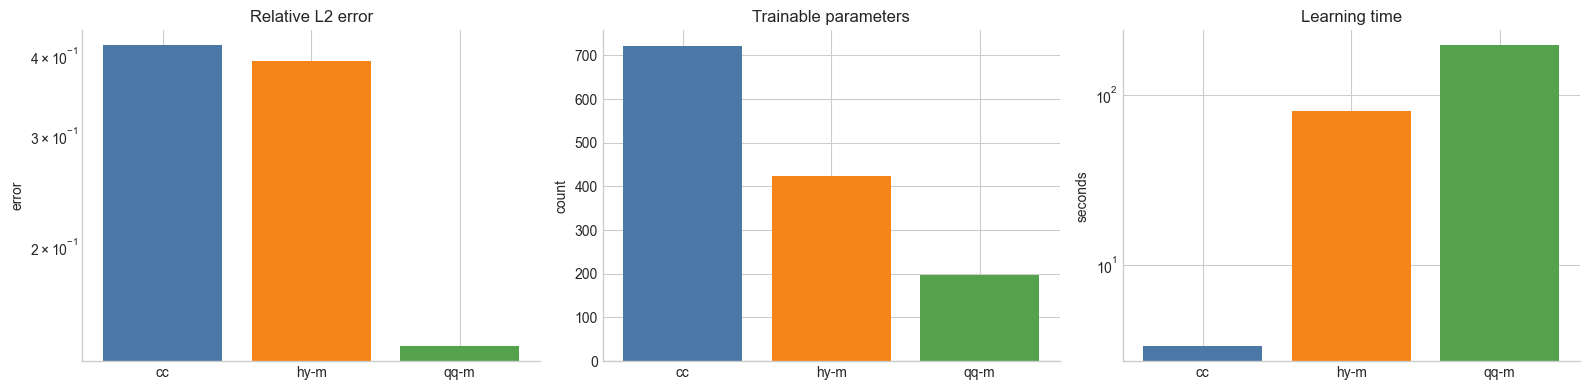

In [20]:
latest_runs = latest_runs_for_models(SUMMARY_PATH, TARGET_MODELS)
if len(latest_runs) != len(TARGET_MODELS):
    raise RuntimeError(f"Expected runs for {TARGET_MODELS}, found {[row['model'] for row in latest_runs]}")

labels = [str(row["model"]) for row in latest_runs]
params = [int(row["params"]) for row in latest_runs]
times = [float(row["elapsed"]) for row in latest_runs]
errors = [float(row["rel_l2"]) for row in latest_runs]
sizes = [str(row["size"]) for row in latest_runs]
colors = [family_color(label) for label in labels]

print("Latest DHO runs used in this notebook")
print("-" * 88)
print(f"{'model':>8} | {'size':>8} | {'params':>10} | {'rel_l2':>12} | {'time_s':>10} | {'run_id':>15}")
print("-" * 88)
for row in latest_runs:
    print(
        f"{str(row['model']):>8} | {str(row['size']):>8} | {int(row['params']):10d} | "
        f"{float(row['rel_l2']):12.4e} | {float(row['elapsed']):10.2f} | {str(row['run_id']):>15}"
    )

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(labels, errors, color=colors)
axes[0].set_title("Relative L2 error")
axes[0].set_ylabel("error")
axes[0].set_yscale("log")

axes[1].bar(labels, params, color=colors)
axes[1].set_title("Trainable parameters")
axes[1].set_ylabel("count")

axes[2].bar(labels, times, color=colors)
axes[2].set_title("Learning time")
axes[2].set_ylabel("seconds")
axes[2].set_yscale("log")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()


## 4. Visual Comparison Of The Learned Trajectories

The final comparison stays qualitative and compact: one final saved figure for each of the three selected models.

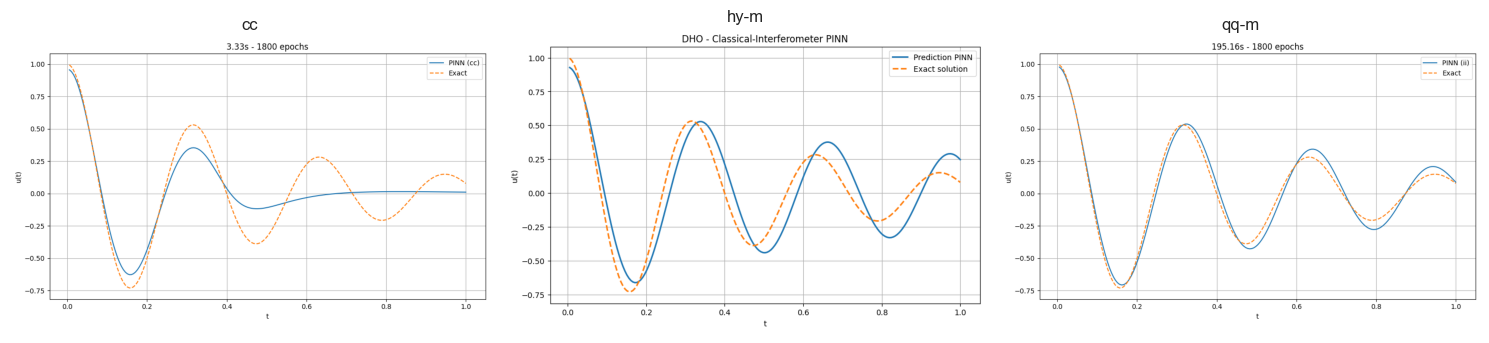

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, model in zip(axes, TARGET_MODELS):
    image_path = final_png_for(model)
    if image_path is None:
        ax.set_title(f"{model}: no png found")
        ax.axis("off")
        continue
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.set_title(model)
    ax.axis("off")

fig.tight_layout()
plt.show()
